### Import Packages


In [1]:
# Let's check the installed tensorflow version
import tensorflow as tf

print("TensorFlow Version is", tf.__version__)

TensorFlow Version is 2.19.0


In [2]:
!pip install matplotlib
!pip install pandas
!pip install scipy
!pip install scikit-learn

In [3]:
import os
import matplotlib.pyplot as plt
import datetime
import numpy as np
import pandas as pd
from tensorflow import keras
from scipy import stats, fft

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_curve,
    auc,
)
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model

### Load Data


In [4]:
## Loading data using pandas

brewing_data_file = "20260421_224126_Brewing_lab8_data.csv"  # normal condition filename: You must change this!
finishing_data_file = "20260422_202458_Finishing_lab8_data.csv"  # abnormal condition filename: You must change this!

df_normal = pd.read_csv(brewing_data_file)  # normal dataframe
df_abnormal = pd.read_csv(finishing_data_file)  # abnormal dataframe

frames = [
    df_normal,
    df_abnormal,
]  # frame list to merge two dataframes into one

df = pd.concat(frames)  # new concatenated dataframe

df  # display dataframe

,Condition,Xacc array [m/s2],Yacc array [m/s2],Zacc array [m/s2]
0,Brewing,-10.4342756 -9.9635564 -10.3558224 -10.1204628...,1.2552512 1.6475172 1.1767979999999998 2.03978...,0.0 -1.2552512 -1.2552512 -1.7259703999999998 ...
1,Brewing,-10.0420096 -10.6696352 -9.571290399999999 -9....,1.569064 1.1767979999999998 0.9414384 1.255251...,-1.8828768 -1.0198916 -0.7060788 -1.8828768 -2...
2,Brewing,-10.0420096 -9.492837199999999 -10.27736919999...,1.4121576 1.6475172 0.392266 0.6276256 1.49061...,-1.3337044 -2.1182364 0.3138128 -0.1569064 -1....
3,Brewing,-9.9635564 -9.8851032 -9.9635564 -10.0420096 -...,1.1767979999999998 1.4906107999999998 1.176797...,-0.3138128 -0.8629851999999999 -1.569064 -0.94...
4,Brewing,-10.198916 -9.80665 -9.8851032 -10.0420096 -9....,1.0983448 1.0198916 1.6475172 1.0198916 1.3337...,-0.8629851999999999 -0.784532 -1.4906107999999...
...,...,...,...,...
55,Finishing,-9.7281968 -9.9635564 -9.022118 -9.64974359999...,1.4121576 1.0198916 1.8044235999999998 0.94143...,0.3138128 -1.4906107999999998 -1.6475172 -1.17...
56,Finishing,-9.8851032 -9.7281968 -9.7281968 -9.8851032 -1...,1.3337044 1.4906107999999998 0.862985199999999...,-1.0198916 -1.0198916 -1.7259703999999998 -1.8...
57,Finishing,-10.0420096 -9.492837199999999 -10.98344800000...,2.1182364 1.8828768 -1.96133 -0.5491724 1.4121...,-0.2353596 -1.6475172 0.6276256 1.804423599999...
58,Finishing,-9.80665 -10.1204628 -9.1005712 -10.0420096 -1...,0.784532 1.3337044 2.1182364 2.1966896 0.15690...,-1.1767979999999998 0.392266 -1.4121576 -1.882...


### Data Transformation


In [5]:
AXIS = "Xacc array [m/s2]"  # in this case, X-axis acceleration data

# Exploding the values contained in selected column and converting the string values into float values
df_new = pd.concat(
    [df["Condition"], df[AXIS].str.split(" ", expand=True).astype(float)],
    axis=1,
)  # transform space delimited array to each value
ds = df_new.copy()  # make ds by copying df

Change the labels 'Brewing' and 'Finishing' into binary notation for model usage


In [6]:
# Converting the Classifier into binary values
ds.loc[df["Condition"] == "Brewing", "Status"] = (
    1  # if Condition column is 'Brewing', Give 'Status' Column 1
)
ds.loc[df["Condition"] == "Finishing", "Status"] = (
    0  # if Condition column is 'Finishing', Give 'Status' Column 0
)
ds.drop(
    "Condition", axis=1, inplace=True
)  # drop 'Condition' column (the first column)

ds  # display ds (dataset)

,0,1,2,3,4,5,6,7,8,9,...,991,992,993,994,995,996,997,998,999,Status
0,-10.434276,-9.963556,-10.355822,-10.120463,-9.728197,-10.198916,-9.806650,-10.591182,-9.728197,-10.042010,...,-10.355822,-10.120463,-10.120463,-10.277369,-9.963556,-10.277369,-10.434276,-9.414384,-10.198916,1.0
1,-10.042010,-10.669635,-9.571290,-9.728197,-10.120463,-10.826542,-8.786758,-9.728197,-9.728197,-9.806650,...,-10.042010,-9.571290,-10.042010,-9.728197,-9.885103,-9.885103,-9.806650,-9.885103,-9.571290,1.0
2,-10.042010,-9.492837,-10.277369,-9.885103,-10.434276,-10.591182,-9.492837,-9.728197,-10.748088,-10.120463,...,-9.571290,-10.277369,-9.885103,-9.571290,-9.806650,-10.434276,-8.943665,-10.434276,-10.120463,1.0
3,-9.963556,-9.885103,-9.963556,-10.042010,-10.591182,-9.649744,-9.806650,-9.963556,-9.414384,-10.120463,...,-10.355822,-9.885103,-9.414384,-9.885103,-9.806650,-9.728197,-9.649744,-9.885103,-10.277369,1.0
4,-10.198916,-9.806650,-9.885103,-10.042010,-9.649744,-10.512729,-10.042010,-10.120463,-10.042010,-9.806650,...,-10.748088,-9.806650,-9.806650,-9.963556,-9.963556,-10.042010,-9.728197,-9.571290,-10.120463,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55,-9.728197,-9.963556,-9.022118,-9.649744,-10.042010,-9.885103,-10.355822,-9.806650,-10.120463,-9.963556,...,-10.120463,-10.120463,-9.414384,-10.042010,-9.885103,-9.963556,-10.434276,-9.728197,-10.355822,0.0
56,-9.885103,-9.728197,-9.728197,-9.885103,-10.198916,-9.649744,-9.571290,-10.355822,-10.042010,-9.806650,...,-9.885103,-10.355822,-10.355822,-10.042010,-10.120463,-9.963556,-9.806650,-10.120463,-9.806650,0.0
57,-10.042010,-9.492837,-10.983448,-9.414384,-10.198916,-10.042010,-10.120463,-10.198916,-9.649744,-9.728197,...,-9.571290,-9.806650,-10.042010,-10.042010,-10.042010,-10.120463,-9.963556,-9.179024,-9.492837,0.0
58,-9.806650,-10.120463,-9.100571,-10.042010,-10.277369,-11.375714,-10.042010,-9.963556,-10.434276,-10.042010,...,-9.728197,-9.806650,-10.198916,-9.728197,-9.492837,-9.963556,-10.042010,-9.963556,-9.728197,0.0


### Training Data Pipe-Line


In [7]:
data = ds.values
# Define Raw data W/O signal processing
raw_data = data[:, :-1]
# Labels: The last column
labels = data[:, -1]

Signal Processing


In [8]:
## signal processing
# Time-domain data
def timeFeatures(data):
    feature = []  # initialize feature list
    for i in range(len(data)):
        mean = np.mean(data[i])  # mean
        std = np.std(data[i])  # standard deviation
        rms = np.sqrt(np.mean(data[i] ** 2))  # root mean squre
        peak = np.max(abs(data[i]))  # peak
        skew = stats.skew(data[i])  # skewness
        kurt = stats.kurtosis(data[i])  # kurtosis
        cf = peak / rms  # crest factor
        # number of feature of each measurement = 7
        feature.append(
            np.array([mean, std, rms, peak, skew, kurt, cf], dtype=float)
        )
    feature = np.array(feature)
    return feature  # feature list, each element is numpy array with datatype float


# DFT magnitude data
def freqFeatures(data):
    feature = []
    for i in range(len(data)):
        N = len(data[i])  # number of data
        yf = (
            2 / N * np.abs(fft.fft(data[i])[: N // 2])
        )  # yf is DFT signal magnitude
        yf[0] = 0
        feature.append(np.array(yf))
    feature = np.array(feature)
    return feature


time_data = timeFeatures(raw_data)  # define time domain feature
freq_data = freqFeatures(raw_data)  # define frequency domain feature (DFT)

In [9]:
## Data (feature) selection and Split training and validation dataset
# Feature selection
input_feature = raw_data  # raw data input without any signal processing
# input_feature = time_data # time domain data
# input_feature = freq_data # frequency data

# get training and test (validation) dataset
train_data, test_data, train_labels, test_labels = train_test_split(
    input_feature, labels, test_size=0.2, random_state=20
)

In [10]:
## Data normalization
def tensorNormalization(data):  # data as numpy array
    min_val = tf.reduce_min(data)  # get min val
    max_val = tf.reduce_max(data)  # get max val
    data_normal = (data - min_val) / (
        max_val - min_val
    )  # get normalized data as numpy array
    return tf.cast(data_normal, tf.float32)  # tensorarray, float 32 datatype


train_data = tensorNormalization(train_data)  # Normalizing train data
test_data = tensorNormalization(test_data)  # Normalizing test data

In [11]:
# Splitting the dataset based on classification: train_labels: Normal, ~train_labels: Abnormal
train_labels = train_labels.astype(
    bool
)  # transform labels as bool (True or False)
test_labels = test_labels.astype(
    bool
)  # in case of 'Normal' it is Ture, if not, False

normal_train_data = train_data[train_labels]  # define normal train data
normal_test_data = test_data[test_labels]  # define normal test data

anomalous_train_data = train_data[~train_labels]  # define abnormal train data
anomalous_test_data = test_data[~test_labels]  # define abnormal test data

portion_of_anomaly_in_training = 0.1  # 10% of training data will be anomalies
end_size = int(
    len(normal_train_data) / (10 - portion_of_anomaly_in_training * 10)
)
combined_train_data = np.append(
    normal_train_data, anomalous_test_data[:end_size], axis=0
)
N_feature = combined_train_data.shape[
    1
]  # get the Number of feature, it depends on your input feature!
print("Number of training dataset is {}.".format(combined_train_data.shape))
print("Number of feature is {}.".format(N_feature))

Number of training dataset is (252, 1000).
Number of feature is 1000.


### Grid Search


In [12]:
class DataSet:
    def __init__(self, axis, data_type="raw"):
        # Exploding the values contained in selected column and converting the string values into float values
        df_new = pd.concat(
            [
                df["Condition"],
                df[axis].str.split(" ", expand=True).astype(float),
            ],
            axis=1,
        )  # transform space delimited array to each value
        ds = df_new.copy()  # make ds by copying df
        # Converting the Classifier into binary values
        ds.loc[df["Condition"] == "Brewing", "Status"] = (
            1  # if Condition column is 'Brewing', Give 'Status' Column 1
        )
        ds.loc[df["Condition"] == "Finishing", "Status"] = (
            0  # if Condition column is 'Finishing', Give 'Status' Column 0
        )
        ds.drop(
            "Condition", axis=1, inplace=True
        )  # drop 'Condition' column (the first column)
        data = ds.values

        # Define Raw data W/O signal processing
        raw_data = data[:, :-1]
        # Labels: The last column
        labels = data[:, -1]

        # get training and test (validation) dataset
        if data_type == "raw":
            input_feature = raw_data
        elif data_type == "time":
            input_feature = timeFeatures(
                raw_data
            )  # define time domain feature
        elif data_type == "freq":
            input_feature = freqFeatures(
                raw_data
            )  # define frequency domain feature (DFT)

        train_data, test_data, train_labels, test_labels = train_test_split(
            input_feature, labels, test_size=0.2, random_state=20
        )

        train_data = tensorNormalization(train_data)  # Normalizing train data
        test_data = tensorNormalization(test_data)  # Normalizing test data

        # Splitting the dataset based on classification: train_labels: Normal, ~train_labels: Abnormal
        train_labels = train_labels.astype(
            bool
        )  # transform labels as bool (True or False)
        test_labels = test_labels.astype(
            bool
        )  # in case of 'Normal' it is Ture, if not, False

        normal_train_data = train_data[
            train_labels
        ]  # define normal train data
        normal_test_data = test_data[test_labels]  # define normal test data

        anomalous_train_data = train_data[
            ~train_labels
        ]  # define abnormal train data
        anomalous_test_data = test_data[
            ~test_labels
        ]  # define abnormal test data

        portion_of_anomaly_in_training = (
            0.1  # 10% of training data will be anomalies
        )
        end_size = int(
            len(normal_train_data) / (10 - portion_of_anomaly_in_training * 10)
        )
        combined_train_data = np.append(
            normal_train_data, anomalous_test_data[:end_size], axis=0
        )

        # Class assignment
        self.normal_train_data = normal_train_data
        self.normal_test_data = normal_test_data
        self.anomalous_train_data = anomalous_train_data
        self.anomalous_test_data = anomalous_test_data
        self.train_data = train_data
        self.test_data = test_data
        self.train_labels = train_labels
        self.test_labels = test_labels
        self.N_feature = input_feature.shape[
            1
        ]  # Make N_feature an instance attribute

In [13]:
class AnomalyDetector(Model):
    def __init__(self, embedding_size, n_feature, **kwargs):
        super(AnomalyDetector, self).__init__(**kwargs)
        self.embedding_size = embedding_size
        self.n_feature = n_feature  # Store n_feature as an attribute
        self.encoder = tf.keras.Sequential(
            [
                layers.Dense(256, activation="relu"),
                layers.Dense(128, activation="relu"),
                layers.Dense(self.embedding_size, activation="relu"),
            ]
        )  # Smallest Layer Defined Here

        self.decoder = tf.keras.Sequential(
            [
                layers.Dense(128, activation="relu"),
                layers.Dense(256, activation="relu"),
                layers.Dense(self.n_feature, activation="sigmoid"),
            ]
        )  # Use n_feature here

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "embedding_size": self.embedding_size,
                "n_feature": self.n_feature,
            }
        )
        return config

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

In [15]:
def find_best_model(
    embedding_sizes, learning_rates, batch_sizes, epochs_list, axes, data_types
):
    tf.random.set_seed(42)
    np.random.seed(42)

    best_roc_auc = 0
    best_model = None
    best_params = None

    results = []
    dataset_cache = {}

    for axis in axes:
        for data_type in data_types:
            # Process data better

            key = (axis, data_type)
            if key not in dataset_cache:
                dataset_cache[key] = DataSet(axis, data_type)
            data = dataset_cache[key]
            val_split = 0.5  # split normal_test into val + test-normal
            split_idx = int(len(data.normal_test_data) * val_split)

            normal_val_data = data.normal_test_data[:split_idx]
            normal_test_data = data.normal_test_data[split_idx:]

            # Final test set (balanced)
            test_data = np.concatenate(
                [normal_test_data, data.anomalous_test_data]
            )

            test_labels = np.concatenate(
                [
                    np.zeros(len(normal_test_data)),
                    np.ones(len(data.anomalous_test_data)),
                ]
            )

            for es in embedding_sizes:
                for lr in learning_rates:
                    for bs in batch_sizes:
                        for ep in epochs_list:

                            tf.keras.backend.clear_session()

                            params = {
                                "Embedding Size": es,
                                "Learning Rate": lr,
                                "Batch Size": bs,
                                "Epoch": ep,
                                "Axis": axis,
                                "Data Type": data_type,
                            }

                            print(params)
                            model = AnomalyDetector(es, data.N_feature)
                            model.compile(
                                optimizer=keras.optimizers.Adam(
                                    learning_rate=lr
                                ),
                                loss="mae",
                            )

                            # Early stopping to reduce time complexity
                            early_stop = EarlyStopping(
                                monitor="val_loss",
                                patience=5,
                                restore_best_weights=True,
                            )

                            model.fit(
                                data.normal_train_data,
                                data.normal_train_data,
                                epochs=ep,
                                batch_size=bs,
                                validation_data=(
                                    normal_val_data,
                                    normal_val_data,
                                ),
                                shuffle=True,
                                verbose=0,
                                callbacks=[early_stop],
                            )

                            # Model evaluation
                            recon = model.predict(test_data, verbose=0)
                            loss = tf.keras.losses.mae(
                                recon, test_data
                            ).numpy()

                            fpr, tpr, _ = roc_curve(test_labels, loss)
                            roc_auc = auc(fpr, tpr)

                            print(f"ROC AUC: {roc_auc:.4f}")

                            results.append(
                                {"params": params, "roc_auc": roc_auc}
                            )

                            if roc_auc > best_roc_auc:
                                print(f"New best: {roc_auc:.4f}")

                                best_roc_auc = roc_auc
                                best_model = model
                                best_params = params
                                # SavedModel directory (NO extension)
                                export_path = "./models/best_model"

                                # build model (keep)
                                try:
                                    dummy_input = tf.zeros((1, data.N_feature))
                                    _ = model(dummy_input)
                                except Exception as e:
                                    print(model.summary())
                                    raise RuntimeError(
                                        f"Error building model: {e}"
                                    )

                                # export SavedModel directory
                                model.export(export_path)

                                print("SavedModel exported to:", export_path)

    return best_model, best_params, results

In [16]:
embedding_size = [32]
learning_rate = [1e-4]
batch_size = [64]
epoch = [200]
axes = ["Yacc array [m/s2]", "Zacc array [m/s2]"]
data_types = ["time", "freq", "raw"]

best_model, best_param, results = find_best_model(
    embedding_size, learning_rate, batch_size, epoch, axes, data_types
)

best_model.summary()

{'Embedding Size': 32, 'Learning Rate': 0.0001, 'Batch Size': 64, 'Epoch': 200, 'Axis': 'Xacc array [m/s2]', 'Data Type': 'time'}
ROC AUC: 0.6278
New best: 0.6278
Saved artifact at './models/best_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  139220663418128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139220663418512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139220663418704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139220663406224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139220663418320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139220663417744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139221863105936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139221863104976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13922186

ROC AUC: 0.6472
{'Embedding Size': 32, 'Learning Rate': 0.0001, 'Batch Size': 64, 'Epoch': 200, 'Axis': 'Yacc array [m/s2]', 'Data Type': 'time'}
ROC AUC: 0.6611
{'Embedding Size': 32, 'Learning Rate': 0.0001, 'Batch Size': 64, 'Epoch': 200, 'Axis': 'Yacc array [m/s2]', 'Data Type': 'freq'}
ROC AUC: 0.7944
New best: 0.7944
Saved artifact at './models/best_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 500), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(None, 500), dtype=tf.float32, name=None)
Captures:
  139220558551312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139220558551120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139220558550928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139217828670800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139217828669072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139217828669456: TensorSpec(shape=(), dtype=tf.resou

Model: "anomaly_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32)             │       165,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 500)            │       165,748 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993,086 (3.79 MB)

 Trainable params: 331,028 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 662,058 (2.53 MB)

### Evaluation Plots


Remake model using best params

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 510ms/step - loss: 0.0549 - val_loss: 0.0540
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0529 - val_loss: 0.0566
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0519 - val_loss: 0.0563
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0509 - val_loss: 0.0542
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0501 - val_loss: 0.0527
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0496 - val_loss: 0.0523
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0492 - val_loss: 0.0529
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0489 - val_loss: 0.0534
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0487 - val_loss: 0.0534
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0485 - val_loss: 0.0528
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0483 - val_loss: 0.0525


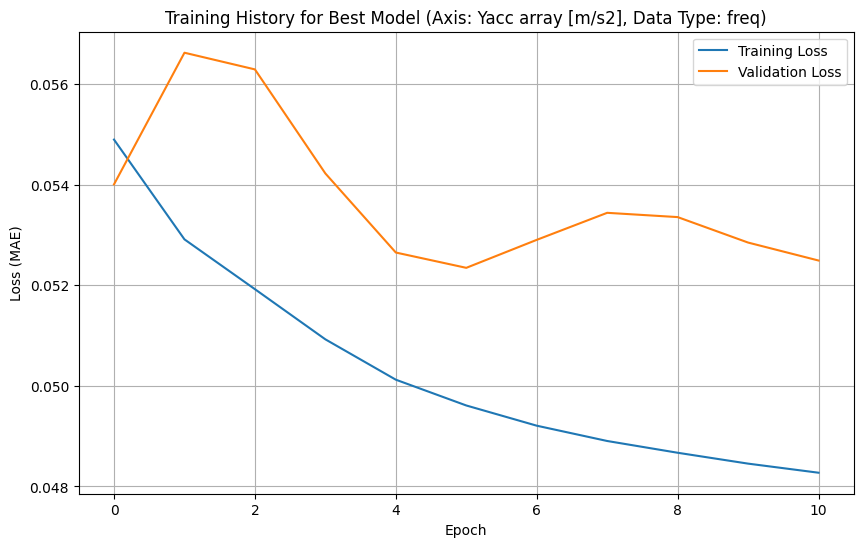

In [17]:
# Recreate the DataSet for the best parameters
best_data = DataSet(best_param["Axis"], best_param["Data Type"])

# Recompile the best_model to prepare it for fitting
best_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_param["Learning Rate"]),
    loss="mae",
)

# Define early stopping as used during the original grid search
early_stop = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

# Prepare validation data, as done in find_best_model
val_split = 0.5
split_idx = int(len(best_data.normal_test_data) * val_split)
normal_val_data = best_data.normal_test_data[:split_idx]

# Re-train the best model to capture its training history
history = best_model.fit(
    best_data.normal_train_data,
    best_data.normal_train_data,
    epochs=best_param["Epoch"],
    batch_size=best_param["Batch Size"],
    validation_data=(normal_val_data, normal_val_data),
    shuffle=True,
    verbose=1,  # Change to 1 to see training progress
    callbacks=[early_stop],
)

# Plotting the evolution of training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title(
    f"Training History for Best Model (Axis: {best_param['Axis']}, Data Type: {best_param['Data Type']})"
)
plt.xlabel("Epoch")
plt.ylabel("Loss (MAE)")
plt.legend()
plt.grid(True)
plt.show()

#### Histogram


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step


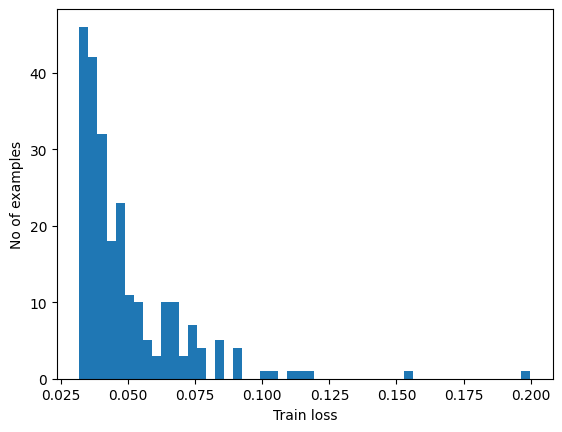

In [21]:
## reconstructions and histogram of training model
reconstructions = best_model.predict(best_data.normal_train_data)
train_loss = tf.keras.losses.mae(reconstructions, best_data.normal_train_data)

plt.hist(train_loss[None, :], bins=50)
plt.xlabel("Train loss")
plt.ylabel("No of examples")
plt.show()

#### Stats


In [24]:
from sklearn.metrics import f1_score, classification_report

## Determining the threshold to detect anomalies
# threshold =  #If you want to assign a value labeled in black in the ROC graph  <-----------------------------------------------------------------------------

threshold = np.mean(train_loss) + np.std(
    train_loss
)  # Common rule of thumb based on the histogram of the train loss
print("Threshold: ", threshold)  # You have to note the threshold you will use


def predict(model, data, threshold):
    reconstructions = model(data)
    loss = tf.keras.losses.mae(reconstructions, data)
    # For anomaly detection, 'True' typically means anomalous. If loss >= threshold, it's predicted as anomalous (True).
    return tf.math.greater_equal(loss, threshold), loss


def print_stats(predictions, labels):
    print("Accuracy = {}".format(accuracy_score(labels, predictions)))
    print("Precision = {}".format(precision_score(labels, predictions)))
    print("Recall = {}".format(recall_score(labels, predictions)))
    print("F1 Score = {}".format(f1_score(labels, predictions)))


# Re-evaluate flipped_labels here for consistency with ROC curve calculation
flipped_labels = 1 - test_labels
preds, scores = predict(best_model, best_data.test_data, threshold)
# Now, preds is True for predicted ANOMALOUS, False for predicted NORMAL
# flipped_labels is True for actual ANOMALOUS, False for actual NORMAL
print_stats(preds, flipped_labels)

Threshold:  0.06974803
Accuracy = 0.8055555555555556
Precision = 0.4166666666666667
Recall = 0.4166666666666667
F1 Score = 0.4166666666666667


### Download Model


In [25]:
!zip -r best_model.zip /content/models/best_model

  adding: content/models/best_model/ (stored 0%)
  adding: content/models/best_model/saved_model.pb (deflated 86%)
  adding: content/models/best_model/variables/ (stored 0%)
  adding: content/models/best_model/variables/variables.index (deflated 64%)
  adding: content/models/best_model/variables/variables.data-00000-of-00001 (deflated 8%)
  adding: content/models/best_model/fingerprint.pb (stored 0%)
  adding: content/models/best_model/assets/ (stored 0%)
